# Does discounts affect customer ratings in e-commerce sales?

This notebook investigates whether there is a relationship between product discounts and customer satisfaction. The analysis uses a synthetic dataset that simulates an e-commerce platform with multiple sellers and product categories. 

A stratified random sample is drawn from the data to simulate constraints on data availability often found in real experiments. A power analysis was conducted to determine sample size.  

The analysis takes a two step approach: first determine whether there is a statistically significant effect in discount orders vs full price in relationship with customer ratings, and investigate whether the magnitude of the discount influences the size of that effect.

**An A/B test and dose-response analysis project.**  
**Dataset:** E-Commerce Data Warehouse (Kaggle)  
**Author:** Joe Laniado  
**Date:** June 2026

## Section 1: Hypothesis & experimental design

### 1.1 Background and motivation
Discounts and promotions are among the most widely used tools in e-commerce. The whole concept stems from the assumption that a product's perceived value is anchored to its original price, so when a discount is applied, the customer believes they 
are obtaining that same value at a lower cost, creating a sense of opportunity.

This raises an interesting question about customer psychology: **If a customer pays less than the listed price, does that alter how they evaluate the product after purchase?**

Two competing effects are plausible:
- Leniency: customers who received a discount may feel they got a good deal and be more lenient when rating the product, regardless of the product's actual quality.
- Quality perception:  a heavily discounted product may signal low demand or poor quality to the customer before purchase, priming them to evaluate it more critically upon receipt.

If either effect is present and measurable, it has direct implications for how businesses develop their pricing strategies. **What if chasing short-term sales volume through discounting risks long-term damage to customer satisfaction?**

### 1.2 Hypotheses
The hypothesis will be defined for each of the two stages of analysis. 

**Stage 1: Binary A/B test: Discount vs full price orders.**

<div style="background-color:#f0f4fb; padding:12px; 
border-left:4px solid #2d4a7a; border-radius:4px; margin:8px 0">
<b>H₀:</b> There is no difference in the distribution of customer ratings between the two groups.<br><br>
<b>H₁:</b> The distribution of customer ratings is different between discount and full price orders.
</div>

A two tailed test will be used, as we dont know the direction of effect if any.

**Stage 2: Dose response analysis: Discount depth buckets.**

<div style="background-color:#f0f4fb; padding:12px; 
border-left:4px solid #2d4a7a; border-radius:4px; margin:8px 0">
<b>H₀:</b> The distribution of customer satisfaction ratings is equal across all discount depth buckets.<br><br>
<b>H₁:</b> At least one discount depth bucket has a different distribution in customer ratings compared to the others.
</div>

It is important to note that the second test will be performed regardless of the outcome of stage 1. Some effects may only be detected at deeper discount levels than if looking at the whole data.

Both stages are tested at a significance level of α = 0.05.



### 1.3 Experiment design


## Section 2: Data exploration and cleaning

### 2.1 Data overview

The data is loaded from the main Fact table and a sample is displayed.

In [61]:
# Data management
import pandas as pd
import numpy as np

# Vizualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Statistics
from scipy import stats
from scipy.stats import mannwhitneyu, kruskal, shapiro, spearmanr, chi2_contingency

print('Libraries imported succesfully.')

Matplotlib is building the font cache; this may take a moment.


In [22]:
# Loading the data.
path = "data/FACT_ORDERS.csv"
data = pd.read_csv(path)

In [35]:
# Display a sample of the data.
data.head().T

,0,1,2,3,4
order_line_id,OL00000001,OL00000002,OL00000003,OL00000004,OL00000005
order_id,ORD0210788,ORD0248321,ORD0377603,ORD0019414,ORD0157859
order_date,2026-02-20 00:00:00,2025-12-02 00:00:00,2025-04-03 00:00:00,2025-06-01 00:00:00,2025-10-25 00:00:00
customer_id,CUST009513,CUST003412,CUST065509,CUST070677,CUST017845
category,Baby,Clothing,Gaming,Home,Pets
seller_rating,4.6,4.0,3.9,4.0,4.5
discount_percentage,9.66,7.04,5.75,0.61,4.41
expected_delivery_date,2026-02-22 00:00:00,2025-12-03 00:00:00,2025-04-05 00:00:00,2025-06-03 00:00:00,2025-10-26 00:00:00
actual_delivery_date,2026-02-22 00:00:00,2025-12-04 00:00:00,2025-04-06 00:00:00,2025-06-03 00:00:00,2025-10-26 00:00:00
customer_rating,4.4,4.3,4.6,4.6,4.0


In [34]:
# Check nulls and data types.
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 790732 entries, 0 to 790731
Data columns (total 15 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   order_line_id           790732 non-null  str           
 1   order_id                790732 non-null  str           
 2   order_date              790732 non-null  datetime64[ns]
 3   customer_id             790732 non-null  str           
 4   category                790732 non-null  str           
 5   seller_rating           751390 non-null  float64       
 6   discount_percentage     790732 non-null  float64       
 7   expected_delivery_date  790732 non-null  datetime64[ns]
 8   actual_delivery_date    790732 non-null  datetime64[ns]
 9   customer_rating         751390 non-null  float64       
 10  order_status            790732 non-null  str           
 11  delivery_rating         751390 non-null  float64       
 12  return_flag             790732 non-null  

In [38]:
# Filter columns relevant to our experiment.
keep_cols = ['order_line_id', 'order_id', 'order_date', 'customer_id', 
             'category', 'seller_rating',  'discount_percentage', 'expected_delivery_date', 
             'actual_delivery_date', 'customer_rating', 'order_status', 'delivery_rating',
             'return_flag','net_amount','unit_price']
df = data[keep_cols].copy()


# Modify data type of date variables.
df = df.astype({
    'order_date':'datetime64[ns]',
    'expected_delivery_date':'datetime64[ns]',
    'actual_delivery_date':'datetime64[ns]'
    })
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 790732 entries, 0 to 790731
Data columns (total 15 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   order_line_id           790732 non-null  str           
 1   order_id                790732 non-null  str           
 2   order_date              790732 non-null  datetime64[ns]
 3   customer_id             790732 non-null  str           
 4   category                790732 non-null  str           
 5   seller_rating           751390 non-null  float64       
 6   discount_percentage     790732 non-null  float64       
 7   expected_delivery_date  790732 non-null  datetime64[ns]
 8   actual_delivery_date    790732 non-null  datetime64[ns]
 9   customer_rating         751390 non-null  float64       
 10  order_status            790732 non-null  str           
 11  delivery_rating         751390 non-null  float64       
 12  return_flag             790732 non-null  

In [37]:
# Describe numerical variables.
df.describe()

,order_date,seller_rating,discount_percentage,expected_delivery_date,actual_delivery_date,customer_rating,delivery_rating,net_amount,unit_price
count,790732,751390.000000,790732.000000,790732,790732,751390.000000,751390.000000,7.907320e+05,7.907320e+05
mean,2025-10-01 12:56:50.624079872,3.934732,4.998254,2025-10-04 04:52:25.690828544,2025-10-04 15:40:51.433861888,3.718927,3.999883,4.334228e+04,1.443109e+04
min,2025-04-02 00:00:00,1.000000,0.000000,2025-04-03 00:00:00,2025-04-03 00:00:00,1.000000,1.000000,6.536000e+01,2.000000e+01
25%,2025-07-02 00:00:00,3.700000,2.500000,2025-07-05 00:00:00,2025-07-05 00:00:00,3.300000,3.600000,1.743271e+03,6.990000e+02
50%,2025-10-01 00:00:00,4.100000,4.990000,2025-10-04 00:00:00,2025-10-05 00:00:00,3.800000,4.200000,5.480861e+03,1.999000e+03
75%,2026-01-01 00:00:00,4.600000,7.500000,2026-01-04 00:00:00,2026-01-04 00:00:00,4.400000,4.600000,2.240403e+04,8.499000e+03
max,2026-04-02 00:00:00,5.000000,10.000000,2026-04-07 00:00:00,2026-04-09 00:00:00,5.000000,5.000000,6.031796e+06,1.150000e+06
std,NaN,0.911800,2.886348,NaN,NaN,0.910232,0.857078,1.672835e+05,5.030919e+04


In [51]:
# Check for null values and duplicates
print(df.isnull().sum(), f"\n\nThe number of duplicate rows in the data is: {df.duplicated().sum()}")

# Drop columns without ratings
df = df.dropna()

order_line_id             0
order_id                  0
order_date                0
customer_id               0
category                  0
seller_rating             0
discount_percentage       0
expected_delivery_date    0
actual_delivery_date      0
customer_rating           0
order_status              0
delivery_rating           0
return_flag               0
net_amount                0
unit_price                0
dtype: int64 

The number of duplicate rows in the data is: 0


In [57]:
# Filtering
df = df.loc[(df['order_status'] == 'Completed') & (df['actual_delivery_date'] <= df['expected_delivery_date'] )]
df = df.drop(columns=['order_status','expected_delivery_date','actual_delivery_date'])
df.info()

<class 'pandas.DataFrame'>
Index: 421156 entries, 0 to 790730
Data columns (total 12 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   order_line_id        421156 non-null  str           
 1   order_id             421156 non-null  str           
 2   order_date           421156 non-null  datetime64[ns]
 3   customer_id          421156 non-null  str           
 4   category             421156 non-null  str           
 5   seller_rating        421156 non-null  float64       
 6   discount_percentage  421156 non-null  float64       
 7   customer_rating      421156 non-null  float64       
 8   delivery_rating      421156 non-null  float64       
 9   return_flag          421156 non-null  bool          
 10  net_amount           421156 non-null  float64       
 11  unit_price           421156 non-null  int64         
dtypes: bool(1), datetime64[ns](1), float64(5), int64(1), str(4)
memory usage: 39.0 MB


In [58]:
print(df.columns)

Index(['order_line_id', 'order_id', 'order_date', 'customer_id', 'category',
       'seller_rating', 'discount_percentage', 'customer_rating',
       'delivery_rating', 'return_flag', 'net_amount', 'unit_price'],
      dtype='str')


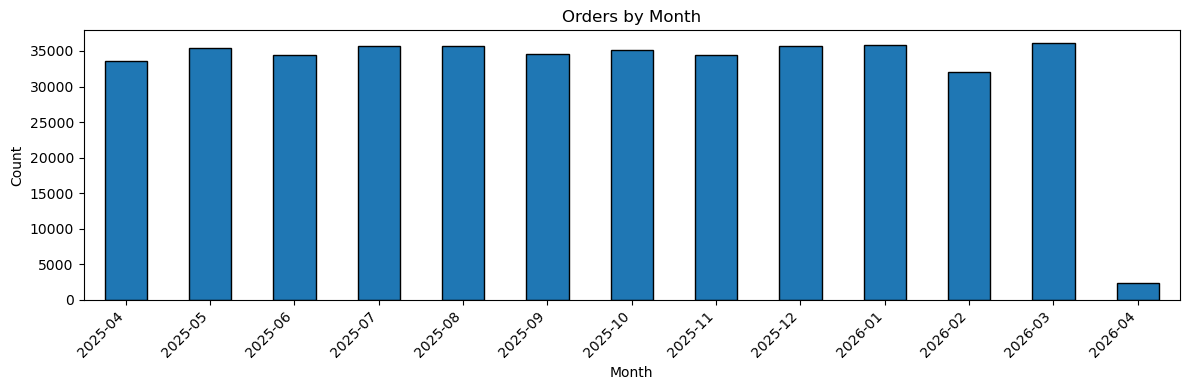

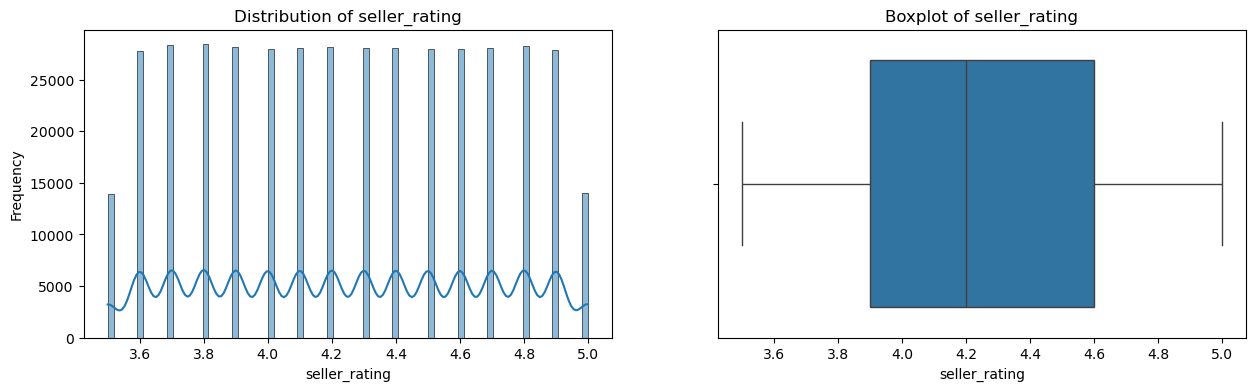

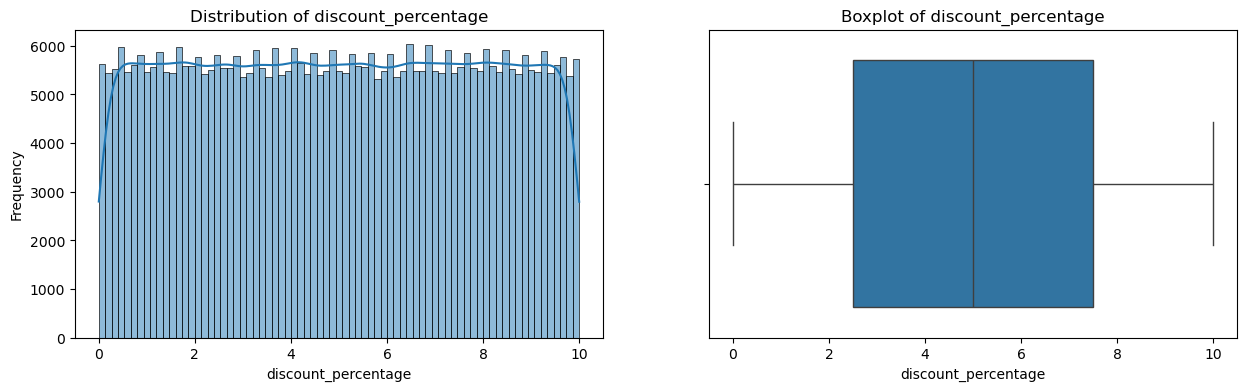

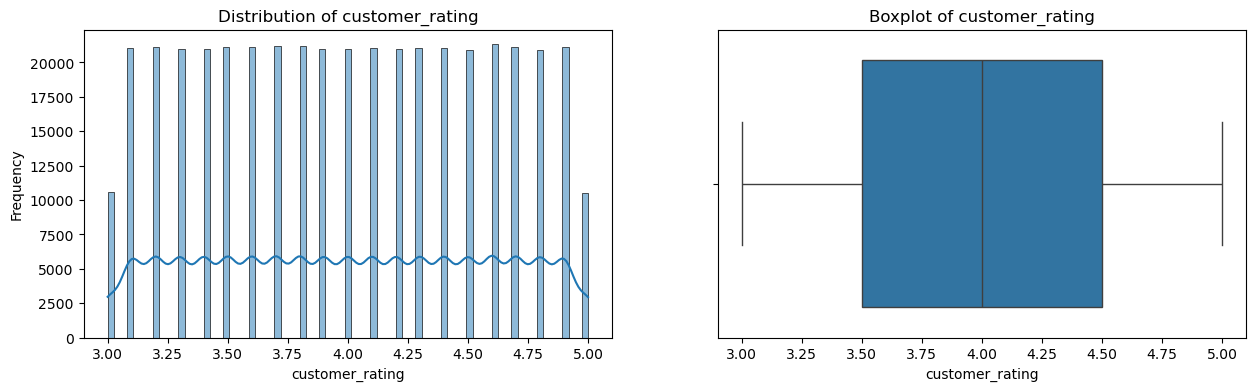

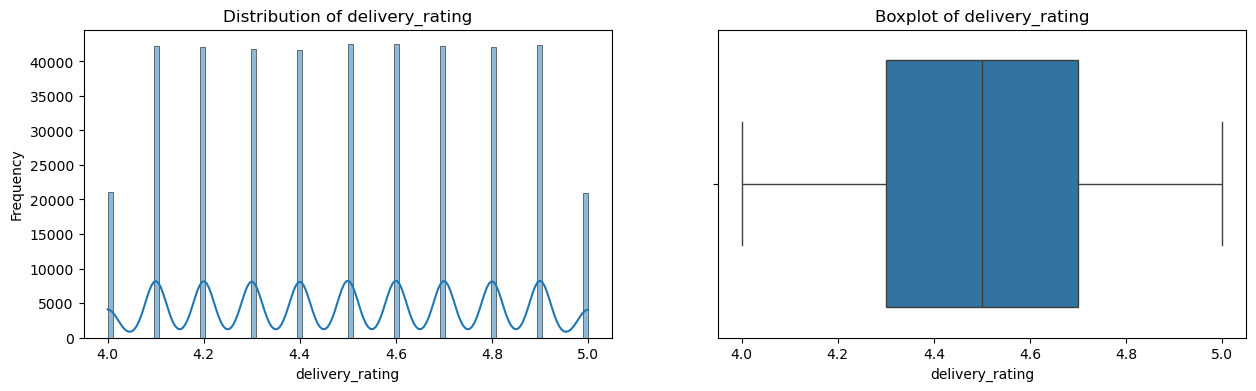

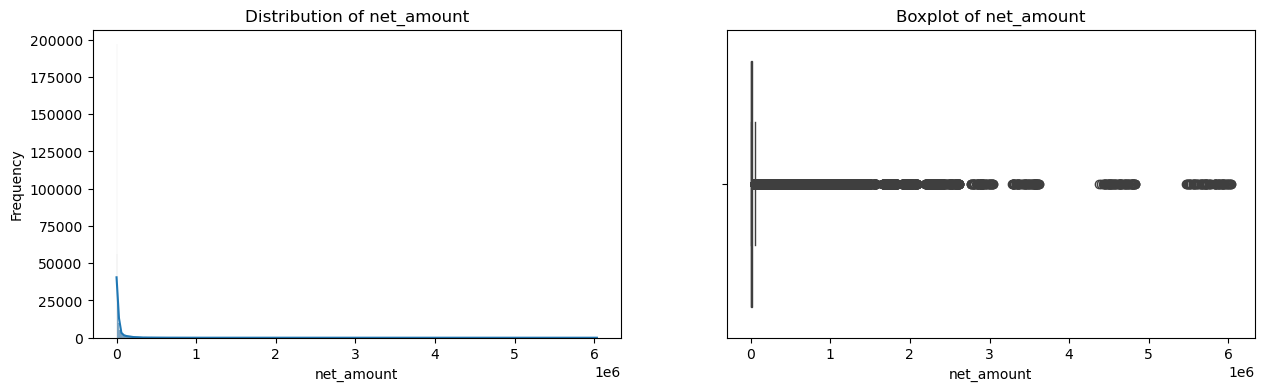

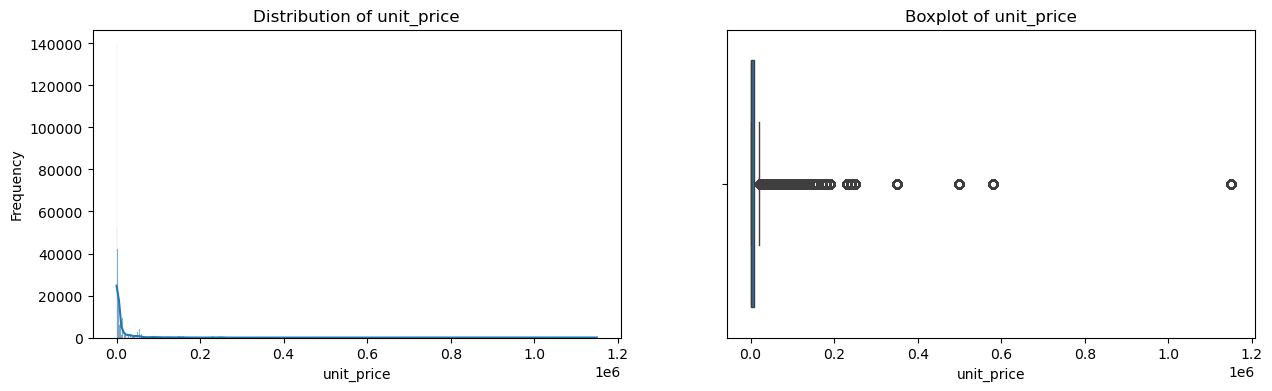

In [64]:
fig, ax = plt.subplots(figsize=(12, 4))

df.groupby(df['order_date'].dt.to_period('M')).size().plot(kind='bar', ax=ax, edgecolor='black')

ax.set_title('Orders by Month')
ax.set_xlabel('Month')
ax.set_ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

for column in df.select_dtypes(include='number'):
    fig, axes = plt.subplots(1,2,figsize=(15,4))
    sns.histplot(data=df, x=column, kde=True, ax=axes[0])
    axes[0].set_title(f'Distribution of {column}')
    axes[0].set_ylabel("Frequency")
    axes[0].set_xlabel(column)

    sns.boxplot(data=df,x=column, ax=axes[1])
    axes[1].set_title(f'Boxplot of {column}')
    plt.show()

    

In [73]:
# Tests for normality
testing_variables = ['net_amount', 'delivery_rating','customer_rating','seller_rating']

for column in testing_variables:
    # Perform Shapiro-Wilk test for normality
    print(f'The p value for {column} is = {shapiro(df[column].sample(500,random_state=42))[1]}')

The p value for net_amount is = 1.900449380153402e-39
The p value for delivery_rating is = 7.581342938130815e-13
The p value for customer_rating is = 7.001695713415495e-11
The p value for seller_rating is = 3.3495313908165837e-12


## Section 4: Power Analysis & Sampling

## Section 5: Group Assignment & EDA on sample

## Section 6: Statistical Tests

### Section 6a: A/B Test

### Section 6b: Dose-response (buckets)

### Section 6c: Combined interpretation

## Section 7: Validation

## Section 8: Conclusion & business recommendation